# Pipeline Dự Báo Doanh Thu & Giá Vốn (MLForecast + LightGBM)

**Tác giả:** Senior Data Scientist — Datathon 2026  
**Mục tiêu:** Dự báo `Revenue` và `COGS` cho 548 ngày (01/01/2023 → 01/07/2024) bằng kiến trúc **Direct Multi-step Forecasting** sử dụng `mlforecast` (Nixtla) + `LightGBM`.

---
**Kiến trúc tổng quan:**
1. Tiền xử lý dữ liệu → Long Format
2. Khai báo CONFIG (tập trung toàn bộ tham số tại đây)
3. Feature Engineering (sự kiện Dương lịch cố định)
4. Huấn luyện & Dự báo (MLForecast)
5. Xuất `submission.csv`
6. Phân tích khả năng giải thích (SHAP)

In [1]:
%pip install shap
%pip install lightgbm
%pip install mlforecast
%pip install window_ops

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# BƯỚC 0: IMPORT THƯ VIỆN
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingMax, RollingMin
from window_ops.rolling import rolling_mean, rolling_max, rolling_min

print("✅ Import thành công.")
print(f"   pandas  : {pd.__version__}")
print(f"   lightgbm: {__import__('lightgbm').__version__}")
print(f"   mlforecast: {__import__('mlforecast').__version__}")

✅ Import thành công.
   pandas  : 2.3.3
   lightgbm: 4.6.0
   mlforecast: 1.0.31


## ⚙️ BƯỚC 1 — CONFIG THAM SỐ

> **TÙY CHỈNH THAM SỐ TẠI ĐÂY** — Toàn bộ hyperparameters, lags, rolling windows và đường dẫn file đều được tập trung trong block `CONFIG` dưới đây. Không cần chỉnh sửa code ở các bước sau.

In [3]:
# ============================================================
# ██████████████  TÙY CHỈNH THAM SỐ TẠI ĐÂY  ██████████████
# ============================================================

CONFIG = {
    # --- Đường dẫn I/O ---
    "input_path": "../data/raw/sales.csv",        # File dữ liệu đầu vào
    "output_dir": "../data/output",               # Thư mục lưu kết quả
    "submission_filename": "submission.csv",      # Tên file nộp bài
    "shap_plot_filename": "shap_summary.png",     # Tên file biểu đồ SHAP

    # --- Cấu hình dự báo ---
    "forecast_horizon": 548,                      # Số ngày dự báo (01/01/2023 → 01/07/2024)
    "forecast_start": "2023-01-01",               # Ngày đầu tiên cần dự báo
    "train_ratio": 0.70,                          # Tỷ lệ dữ liệu huấn luyện (70% đầu theo thời gian)
    "date_col": "Date",                           # Tên cột ngày trong sales.csv
    "target_cols": ["Revenue", "COGS"],           # Các cột cần dự báo

    # --- LightGBM Hyperparameters ---
    # Ghi chú: Điều chỉnh n_estimators và learning_rate cùng nhau
    #          (learning_rate thấp → cần n_estimators cao hơn)
    "lgbm_params": {
        "n_estimators": 1332,          # Số cây quyết định (boosting rounds)
        "learning_rate":  0.04759155708560107,         # Tốc độ học (shrinkage)
        "max_depth": 6,                # Độ sâu tối đa mỗi cây
        "num_leaves": 68,              # Số lá tối đa (2^max_depth - 1)
        "min_child_samples": 19,       # Số mẫu tối thiểu trong một lá
        "subsample": 0.688363529336043,             # Tỷ lệ mẫu dùng mỗi cây (bagging)
        "colsample_bytree": 0.8975121712165626,      # Tỷ lệ feature dùng mỗi cây
        "reg_alpha": 0.06536060672182367,              # Regularization L1 (lasso)
        "reg_lambda": 0.049218052992262784,             # Regularization L2 (ridge)
        "random_state": 2404,
        "n_jobs": -1,
        "verbose": -1,
    },

    # --- Lags (Biến trễ) ---
    # Ghi chú:
    #   lag_7   → Chu kỳ tuần (weekly seasonality)
    #   lag_30  → Chu kỳ tháng (monthly seasonality)
    #   lag_354 → Chu kỳ năm Âm lịch (~354 ngày): bắt HIỆU ỨNG TẾT NGUYÊN ĐÁN
    #   lag_365 → Chu kỳ năm Dương lịch (bắt tính mùa vụ chính xác theo dương lịch)
    "lags": [1, 2, 3, 7, 14, 21, 30, 60, 90, 180, 354, 365],

    # --- Rolling Window Transforms ---
    # Tính toán đặc trưng thống kê trên cửa sổ trượt
    # window_size=7   → Xu hướng ngắn hạn (short-term trend)
    # window_size=30  → Xu hướng trung hạn (medium-term trend)
    # min_samples=1   → Cho phép tính ngay từ đầu series (tránh NaN)
    "rolling_windows": {
        "mean": {"window_sizes": [7, 30], "min_samples": 1},
        "max":  {"window_sizes": [7, 30], "min_samples": 1},
        "min":  {"window_sizes": [7, 30], "min_samples": 1},
    },

    # --- Date Features (Đặc trưng từ ngày tháng) ---
    # Trích xuất trực tiếp từ cột ds — KHÔNG dùng dữ liệu ngoài
    "date_features": ["dayofweek", "month", "day", "dayofyear"],

    # --- Gregorian Peak Dates (Ngày đỉnh Dương lịch cố định) ---
    # Các dải ngày có chu kỳ mua sắm cao theo lịch Dương lịch
    "gregorian_peaks": [
        {"months": [2],  "days": range(12, 15)},   # Valentine / Pre-Tết (12-14/02)
        {"months": [3],  "days": range(6,  9)},    # Ngày Quốc tế Phụ nữ (06-08/03)
        {"months": [4],  "days": range(28, 31)},   # Trước lễ 30/04 (28-30/04)
        {"months": [5],  "days": [1]},             # Quốc tế Lao động (01/05)
        {"months": [9],  "days": [1, 2]},          # Quốc khánh (01-02/09)
        {"months": [12], "days": range(20, 32)},   # Mùa mua sắm cuối năm (20-31/12)
    ],
}

# Đảm bảo thư mục output tồn tại
os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("✅ CONFIG đã được nạp.")
print(f"   Horizon       : {CONFIG['forecast_horizon']} ngày")
print(f"   Train ratio    : {CONFIG['train_ratio']*100:.0f}% / Test ratio: {(1-CONFIG['train_ratio'])*100:.0f}%")
print(f"   Lags           : {CONFIG['lags']}")
print(f"   Rolling windows: {list(CONFIG['rolling_windows']['mean']['window_sizes'])}")

✅ CONFIG đã được nạp.
   Horizon       : 548 ngày
   Train ratio    : 70% / Test ratio: 30%
   Lags           : [1, 2, 3, 7, 14, 21, 30, 60, 90, 180, 354, 365]
   Rolling windows: [7, 30]


## 📥 BƯỚC 2 — TIỀN XỬ LÝ DỮ LIỆU

Đọc `sales.csv` và chuyển đổi từ định dạng **Wide** (Revenue, COGS là các cột) sang định dạng **Long** bắt buộc của `mlforecast`:

| `unique_id` | `ds`       | `y`   |
|-------------|------------|-------|
| `Revenue`   | 2020-01-01 | 123.4 |
| `COGS`      | 2020-01-01 | 89.2  |

> `unique_id`: định danh time series (Revenue hoặc COGS)  
> `ds`: cột datetime  
> `y`: giá trị cần dự báo

In [4]:
# ============================================================
# BƯỚC 2: ĐỌC & CHUYỂN SANG LONG FORMAT
# ============================================================

def load_and_melt(filepath: str, date_col: str, target_cols: list) -> pd.DataFrame:
    """
    Đọc file CSV, parse ngày tháng và chuyển đổi từ Wide sang Long format
    phù hợp với mlforecast (cột: unique_id, ds, y).

    Parameters
    ----------
    filepath    : đường dẫn tới file CSV
    date_col    : tên cột ngày trong CSV
    target_cols : danh sách tên cột cần dự báo

    Returns
    -------
    pd.DataFrame với cột [unique_id, ds, y]
    """
    df_wide = pd.read_csv(filepath, parse_dates=[date_col])
    df_wide = df_wide.rename(columns={date_col: "ds"})

    # Kiểm tra dữ liệu đầu vào
    missing = df_wide[target_cols].isnull().sum()
    if missing.any():
        print(f"⚠️  Phát hiện giá trị NULL:\n{missing[missing > 0]}")
        # Nội suy tuyến tính để lấp đầy giá trị thiếu
        df_wide[target_cols] = df_wide[target_cols].interpolate(method="linear")

    # Melt: Wide → Long
    df_long = df_wide.melt(
        id_vars=["ds"],
        value_vars=target_cols,
        var_name="unique_id",
        value_name="y",
    )

    # mlforecast yêu cầu sort theo unique_id rồi ds
    df_long = df_long.sort_values(["unique_id", "ds"]).reset_index(drop=True)

    return df_long


# --- Thực thi ---
df_long = load_and_melt(
    filepath=CONFIG["input_path"],
    date_col=CONFIG["date_col"],
    target_cols=CONFIG["target_cols"],
)

print(f"✅ Đã tải và chuyển đổi sang Long Format.")
print(f"   Shape         : {df_long.shape}")
print(f"   unique_id     : {df_long['unique_id'].unique().tolist()}")
print(f"   Khoảng thời gian: {df_long['ds'].min().date()} → {df_long['ds'].max().date()}")
print(f"   Số ngày/series: {df_long.groupby('unique_id')['ds'].count().to_dict()}")
df_long.head(4)

✅ Đã tải và chuyển đổi sang Long Format.
   Shape         : (7666, 3)
   unique_id     : ['COGS', 'Revenue']
   Khoảng thời gian: 2012-07-04 → 2022-12-31
   Số ngày/series: {'COGS': 3833, 'Revenue': 3833}


,ds,unique_id,y
0,2012-07-04,COGS,3982991.19
1,2012-07-05,COGS,2150580.23
2,2012-07-06,COGS,2517632.84
3,2012-07-07,COGS,2108246.62


In [5]:
# ============================================================
# BƯỚC 2.5: PHÂN CHIA DỮ LIỆU — TRAIN / TEST (70% / 30%)
# ============================================================
# NGUYÊN TẮC QUAN TRỌNG trong Time Series Forecasting:
#   - KHÔNG split ngẫu nhiên (random split sẽ gây data leakage từ tương lai).
#   - Luôn split theo thứ tự thời gian (temporal split):
#       70% ngày đầu tiên → tập Train (huấn luyện)
#       30% ngày cuối cùng → tập Test  (đánh giá độ chính xác)

def temporal_split(df_long: pd.DataFrame, train_ratio: float) -> tuple:
    """
    Phân chia Long Format DataFrame theo thứ tự thời gian (temporal split).

    Parameters
    ----------
    df_long     : DataFrame Long Format (unique_id, ds, y)
    train_ratio : tỷ lệ dữ liệu dùng để huấn luyện (VD: 0.70)

    Returns
    -------
    (df_train, df_test, cutoff_date)
    """
    # Lấy tất cả ngày duy nhất, sắp xếp tăng dần
    all_dates = np.sort(df_long["ds"].unique())
    n_test = 548
    # n_train   = int(len(all_dates) * train_ratio)
    n_train = len(all_dates) - n_test

    # Ngày cuối cùng thuộc tập Train
    cutoff = pd.Timestamp(all_dates[n_train - 1])

    df_train = df_long[df_long["ds"] <= cutoff].reset_index(drop=True)
    df_test  = df_long[df_long["ds"] >  cutoff].reset_index(drop=True)

    return df_train, df_test, cutoff


# --- Thực thi split ---
df_train, df_test, cutoff_date = temporal_split(
    df_long,
    train_ratio=CONFIG["train_ratio"],
)

n_total = df_long["ds"].nunique()
n_train = df_train["ds"].nunique()
n_test  = df_test["ds"].nunique()

print("✅ Phân chia Train / Test hoàn thành.")
print(f"   Tổng số ngày   : {n_total}")
print(f"   ├─ Train ({CONFIG['train_ratio']*100:.0f}%): {n_train} ngày  "
      f"({df_train['ds'].min().date()} → {df_train['ds'].max().date()})")
print(f"   └─ Test  ({(1-CONFIG['train_ratio'])*100:.0f}%): {n_test} ngày  "
      f"({df_test['ds'].min().date()} → {df_test['ds'].max().date()})")
print(f"   Cutoff date    : {cutoff_date.date()}")

✅ Phân chia Train / Test hoàn thành.
   Tổng số ngày   : 3833
   ├─ Train (70%): 3285 ngày  (2012-07-04 → 2021-07-01)
   └─ Test  (30%): 548 ngày  (2021-07-02 → 2022-12-31)
   Cutoff date    : 2021-07-01


## 🗓️ BƯỚC 3 — FEATURE ENGINEERING: SỰ KIỆN DƯƠNG LỊCH CỐ ĐỊNH

Hàm `add_gregorian_peaks(df)` được thiết kế để nhận diện các **dải ngày Dương lịch** có tính chu kỳ mua sắm cao. Đây là các sự kiện **có thể dự đoán trước** (deterministic), không yêu cầu dữ liệu ngoài.

Ví dụ:
- **12-14/02**: Hiệu ứng Valentine / giai đoạn sát Tết Dương lịch
- **20-31/12**: Mùa mua sắm cuối năm (Christmas season, New Year prep)

In [6]:
# ============================================================
# BƯỚC 3: FEATURE ENGINEERING — SỰ KIỆN DƯƠNG LỊCH CỐ ĐỊNH
# ============================================================
# Lưu ý về API của mlforecast:
#   date_features nhận callable với signature: fn(DatetimeIndex) → pd.Series
#   Tên hàm tự động trở thành tên cột feature, được áp dụng cho cả
#   train và predict mà không cần truyền thủ công.

def is_gregorian_peak(dates: pd.DatetimeIndex) -> pd.Series:
    """
    Date feature callable tương thích với MLForecast.

    Nhận vào DatetimeIndex (do MLForecast cung cấp tự động),
    trả về pd.Series nhị phân:
        1 → ngày nằm trong dải peak Dương lịch có chu kỳ mua sắm cao
        0 → ngày bình thường

    Tên hàm ('is_gregorian_peak') tự động trở thành tên cột feature.

    Parameters
    ----------
    dates : pd.DatetimeIndex

    Returns
    -------
    pd.Series[int8] với name='is_gregorian_peak'
    """
    day   = dates.day.to_numpy()
    month = dates.month.to_numpy()

    mask = np.zeros(len(dates), dtype=np.int8)

    for peak_rule in CONFIG["gregorian_peaks"]:
        in_month = np.isin(month, list(peak_rule["months"]))
        in_day   = np.isin(day,   list(peak_rule["days"]))
        mask    |= (in_month & in_day).astype(np.int8)

    return pd.Series(mask, index=range(len(dates)), name="is_gregorian_peak")


# Kiểm tra nhanh: đếm số ngày peak trong 1 năm bất kỳ
_test_idx    = pd.date_range("2022-01-01", periods=365, freq="D")
_test_series = is_gregorian_peak(_test_idx)

print(f"✅ Hàm is_gregorian_peak hoạt động đúng.")
print(f"   Số ngày peak trong năm 2022: {int(_test_series.sum())} / 365")

peak_days = _test_idx[_test_series.values == 1].strftime("%d/%m").tolist()
print(f"   Danh sách: {peak_days}")

✅ Hàm is_gregorian_peak hoạt động đúng.
   Số ngày peak trong năm 2022: 24 / 365
   Danh sách: ['12/02', '13/02', '14/02', '06/03', '07/03', '08/03', '28/04', '29/04', '30/04', '01/05', '01/09', '02/09', '20/12', '21/12', '22/12', '23/12', '24/12', '25/12', '26/12', '27/12', '28/12', '29/12', '30/12', '31/12']


## 🤖 BƯỚC 4 — HUẤN LUYỆN & DỰ BÁO (MLForecast)

### Kiến trúc Direct Multi-step Forecasting

- `MLForecast` huấn luyện **một mô hình riêng biệt cho mỗi step** từ 1 đến 548.  
- Điều này tránh tích lũy sai số (error accumulation) so với phương pháp recursive.  
- `lag_transforms` sử dụng `window_ops` để tính rolling mean/max/min hiệu quả trên C layer.

### Vai trò của Lag 354 và Lag 365
| Lag  | Ý nghĩa kinh doanh |
|------|---------------------|
| 354  | **Năm Âm lịch** (~354 ngày/năm). Bắt hiệu ứng Tết Nguyên Đán dịch chuyển theo dương lịch. |
| 365  | **Năm Dương lịch**. Bắt tính mùa vụ cố định (lễ Tết dương, mùa hè, cuối năm). |

In [7]:
# ============================================================
# BƯỚC 4: SETUP & HUẤN LUYỆN MLFORECAST
# ============================================================

# --- 4.1 Xây dựng lag_transforms từ CONFIG ---
lag_transforms = {}

rw_cfg = CONFIG["rolling_windows"]
for win in rw_cfg["mean"]["window_sizes"]:
    min_s = rw_cfg["mean"]["min_samples"]
    lag_transforms[win] = [
        RollingMean(window_size=win, min_samples=min_s),
        RollingMax(window_size=win,  min_samples=min_s),
        RollingMin(window_size=win,  min_samples=min_s),
    ]

print("🔧 Lag transforms được cấu hình:")
for k, v in lag_transforms.items():
    print(f"   lag_{k}: {[type(t).__name__ for t in v]}")


# --- 4.2 Khởi tạo mô hình LightGBM ---
lgbm_model = LGBMRegressor(**CONFIG["lgbm_params"])


# --- 4.3 Khởi tạo MLForecast ---
# is_gregorian_peak được đăng ký vào date_features như một callable.
# MLForecast tự động gọi fn(DatetimeIndex) → pd.Series tại cả fit() lẫn predict().
fcst = MLForecast(
    models={"LightGBM": lgbm_model},
    freq="D",
    lags=CONFIG["lags"],
    lag_transforms=lag_transforms,
    date_features=CONFIG["date_features"] + [is_gregorian_peak],   # ← callable
    num_threads=4,
)

print("\n✅ MLForecast đã được khởi tạo.")
print(f"   Lags        : {CONFIG['lags']}")
print(f"   Date features: {CONFIG['date_features'] + ['is_gregorian_peak']}")


# --- 4.4 Preprocess: kiểm tra feature matrix trên tập Train ---
print("\n⏳ Đang preprocess & tạo feature matrix (trên tập Train)...")
X_train_df = fcst.preprocess(df_train, static_features=[])

print(f"✅ Preprocess hoàn thành.")
print(f"   Feature matrix shape: {X_train_df.shape}")
print(f"   Các features: {X_train_df.columns.tolist()}")

🔧 Lag transforms được cấu hình:
   lag_7: ['RollingMean', 'RollingMax', 'RollingMin']
   lag_30: ['RollingMean', 'RollingMax', 'RollingMin']

✅ MLForecast đã được khởi tạo.
   Lags        : [1, 2, 3, 7, 14, 21, 30, 60, 90, 180, 354, 365]
   Date features: ['dayofweek', 'month', 'day', 'dayofyear', 'is_gregorian_peak']

⏳ Đang preprocess & tạo feature matrix (trên tập Train)...
✅ Preprocess hoàn thành.
   Feature matrix shape: (5840, 26)
   Các features: ['ds', 'unique_id', 'y', 'lag1', 'lag2', 'lag3', 'lag7', 'lag14', 'lag21', 'lag30', 'lag60', 'lag90', 'lag180', 'lag354', 'lag365', 'rolling_mean_lag7_window_size7_min_samples1', 'rolling_max_lag7_window_size7_min_samples1', 'rolling_min_lag7_window_size7_min_samples1', 'rolling_mean_lag30_window_size30_min_samples1', 'rolling_max_lag30_window_size30_min_samples1', 'rolling_min_lag30_window_size30_min_samples1', 'dayofweek', 'month', 'day', 'dayofyear', 'is_gregorian_peak']


In [8]:
# --- 4.5 Huấn luyện mô hình trên tập Train (70%) ---
print(f"⏳ Đang huấn luyện LightGBM trên tập Train "
      f"({CONFIG['train_ratio']*100:.0f}% lịch sử)...")

fcst.fit(df_train, static_features=[])

print("✅ Huấn luyện hoàn thành.")
print(f"   Khoảng dữ liệu train: "
      f"{df_train['ds'].min().date()} → {df_train['ds'].max().date()}")

⏳ Đang huấn luyện LightGBM trên tập Train (70% lịch sử)...
✅ Huấn luyện hoàn thành.
   Khoảng dữ liệu train: 2012-07-04 → 2021-07-01


In [9]:
# ============================================================
# BƯỚC 4.5: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST (30%)
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_horizon = df_test["ds"].nunique()
print(f"⏳ Dự báo {test_horizon} ngày để đánh giá trên tập Test (30%)...")

forecast_eval_long = fcst.predict(h=test_horizon)

# Ghép kết quả dự báo với giá trị thực tế của tập Test
eval_df = forecast_eval_long.merge(
    df_test[["unique_id", "ds", "y"]],
    on=["unique_id", "ds"],
    how="inner",
)

print(f"\n{'='*58}")
print(f"{'📊  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (30%)':^58}")
print(f"{'='*58}")
print(f"{'Metric':<18} {'Revenue':>19} {'COGS':>19}")
print(f"{'-'*58}")

eval_results = {}
for uid in CONFIG["target_cols"]:
    mask   = eval_df["unique_id"] == uid
    y_true = eval_df.loc[mask, "y"].values
    y_pred = eval_df.loc[mask, "LightGBM"].values
    safe_y = np.where(np.abs(y_true) < 1e-8, 1e-8, y_true)
    eval_results[uid] = {
        "MAE":     mean_absolute_error(y_true, y_pred),
        "RMSE":    np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²":      r2_score(y_true, y_pred),
        "MAPE(%)": np.mean(np.abs((y_true - y_pred) / safe_y)) * 100,
    }

for metric in ["MAE", "RMSE", "R²", "MAPE(%)"]:
    rev  = eval_results["Revenue"][metric]
    cogs = eval_results["COGS"][metric]
    if metric == "R²":
        print(f"{metric:<18} {rev:>19.4f} {cogs:>19.4f}")
    elif metric == "MAPE(%)":
        print(f"{metric:<18} {rev:>18.2f}% {cogs:>18.2f}%")
    else:
        print(f"{metric:<18} {rev:>19,.2f} {cogs:>19,.2f}")

print(f"{'='*58}")
print(f"\n📌 Ngưỡng tham khảo: R² ≥ 0.90 → mô hình giải thích ≥ 90% phương sai.")

⏳ Dự báo 548 ngày để đánh giá trên tập Test (30%)...

         📊  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (30%)          
Metric                         Revenue                COGS
----------------------------------------------------------
MAE                         638,697.59          562,518.38
RMSE                        850,974.23          742,224.26
R²                              0.6998              0.7053
MAPE(%)                         26.10%              25.23%

📌 Ngưỡng tham khảo: R² ≥ 0.90 → mô hình giải thích ≥ 90% phương sai.


In [10]:
# ============================================================
# BƯỚC 4.6: TÁI HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU (100%)
# ============================================================
print("⏳ Tái huấn luyện LightGBM trên 100% dữ liệu lịch sử...")
fcst.fit(df_long, static_features=[])
print("✅ Tái huấn luyện hoàn thành.")
print(f"   Khoảng dữ liệu full: "
      f"{df_long['ds'].min().date()} → {df_long['ds'].max().date()}")

# --- Dự báo 548 bước tương lai cho submission ---
print(f"\n⏳ Đang dự báo {CONFIG['forecast_horizon']} ngày tới...")
forecast_long = fcst.predict(h=CONFIG["forecast_horizon"])

print(f"✅ Dự báo hoàn thành.")
print(f"   Shape kết quả (Long): {forecast_long.shape}")
print(f"   Ngày đầu dự báo     : {forecast_long['ds'].min().date()}")
print(f"   Ngày cuối dự báo    : {forecast_long['ds'].max().date()}")
forecast_long.head(6)

⏳ Tái huấn luyện LightGBM trên 100% dữ liệu lịch sử...
✅ Tái huấn luyện hoàn thành.
   Khoảng dữ liệu full: 2012-07-04 → 2022-12-31

⏳ Đang dự báo 548 ngày tới...
✅ Dự báo hoàn thành.
   Shape kết quả (Long): (1096, 3)
   Ngày đầu dự báo     : 2023-01-01
   Ngày cuối dự báo    : 2024-07-01


,unique_id,ds,LightGBM
0,COGS,2023-01-01,1.794530e+06
1,COGS,2023-01-02,1.447346e+06
2,COGS,2023-01-03,9.129220e+05
3,COGS,2023-01-04,7.929013e+05
4,COGS,2023-01-05,8.705841e+05
5,COGS,2023-01-06,1.100854e+06


## 💾 BƯỚC 5 — XUẤT KẾT QUẢ (`submission.csv`)

Chuyển (Pivot) dữ liệu dự báo từ **Long format** trở lại **Wide format** (`Date`, `Revenue`, `COGS`) và lưu ra file `submission.csv`.

In [11]:
# ============================================================
# BƯỚC 5: PIVOT LONG → WIDE VÀ LƯU submission.csv
# ============================================================

def pivot_to_wide(forecast_long: pd.DataFrame, model_col: str = "LightGBM") -> pd.DataFrame:
    """
    Chuyển kết quả dự báo từ Long format (unique_id, ds, prediction)
    sang Wide format (Date, Revenue, COGS) theo yêu cầu nộp bài.

    Parameters
    ----------
    forecast_long : DataFrame từ fcst.predict()
    model_col     : tên cột chứa giá trị dự báo (= tên model đã đặt)

    Returns
    -------
    pd.DataFrame với cột [Date, Revenue, COGS]
    """
    # Pivot: unique_id thành cột, ds thành index
    df_wide = forecast_long.pivot(
        index="ds",
        columns="unique_id",
        values=model_col,
    ).reset_index()

    df_wide = df_wide.rename(columns={"ds": "Date"})
    df_wide.columns.name = None  # Xóa tên index phụ sau pivot

    # Đảm bảo thứ tự cột đúng theo yêu cầu nộp bài
    col_order = ["Date"] + CONFIG["target_cols"]
    df_wide = df_wide[col_order]

    # Làm tròn giá trị dự báo về 2 chữ số thập phân
    for col in CONFIG["target_cols"]:
        df_wide[col] = df_wide[col].round(2)

    return df_wide


# Pivot về Wide format
submission = pivot_to_wide(forecast_long, model_col="LightGBM")

# Kiểm tra ngày đầu / cuối đúng với yêu cầu bài thi
assert str(submission["Date"].min().date()) == CONFIG["forecast_start"], (
    f"❌ Ngày bắt đầu sai: {submission['Date'].min().date()} (kỳ vọng {CONFIG['forecast_start']})"
)
assert len(submission) == CONFIG["forecast_horizon"], (
    f"❌ Số dòng sai: {len(submission)} (kỳ vọng {CONFIG['forecast_horizon']})"
)

# Lưu file
output_path = os.path.join(CONFIG["output_dir"], CONFIG["submission_filename"])
submission.to_csv(output_path, index=False, date_format="%Y-%m-%d")

print(f"✅ Đã lưu submission.csv.")
print(f"   Đường dẫn  : {output_path}")
print(f"   Số dòng    : {len(submission)}")
print(f"   Ngày đầu   : {submission['Date'].min().date()}")
print(f"   Ngày cuối  : {submission['Date'].max().date()}")
print(f"\n--- Mẫu kết quả (5 dòng đầu) ---")
display(submission.head())
print(f"\n--- Mẫu kết quả (5 dòng cuối) ---")
display(submission.tail())

✅ Đã lưu submission.csv.
   Đường dẫn  : ../data/output\submission.csv
   Số dòng    : 548
   Ngày đầu   : 2023-01-01
   Ngày cuối  : 2024-07-01

--- Mẫu kết quả (5 dòng đầu) ---


,Date,Revenue,COGS
0,2023-01-01,1968912.23,1794530.13
1,2023-01-02,1426267.36,1447346.20
2,2023-01-03,927130.61,912922.03
3,2023-01-04,1010206.97,792901.27
4,2023-01-05,942371.79,870584.13



--- Mẫu kết quả (5 dòng cuối) ---


,Date,Revenue,COGS
543,2024-06-27,4983819.91,5298073.29
544,2024-06-28,5205026.59,4380104.77
545,2024-06-29,4460398.75,4294667.85
546,2024-06-30,5445867.38,5101638.76
547,2024-07-01,4506299.95,4779860.24


## 📊 BƯỚC 6 — TRỰC QUAN HÓA DỰ BÁO

So sánh dữ liệu lịch sử với kết quả dự báo để kiểm tra tính hợp lý (sanity check).

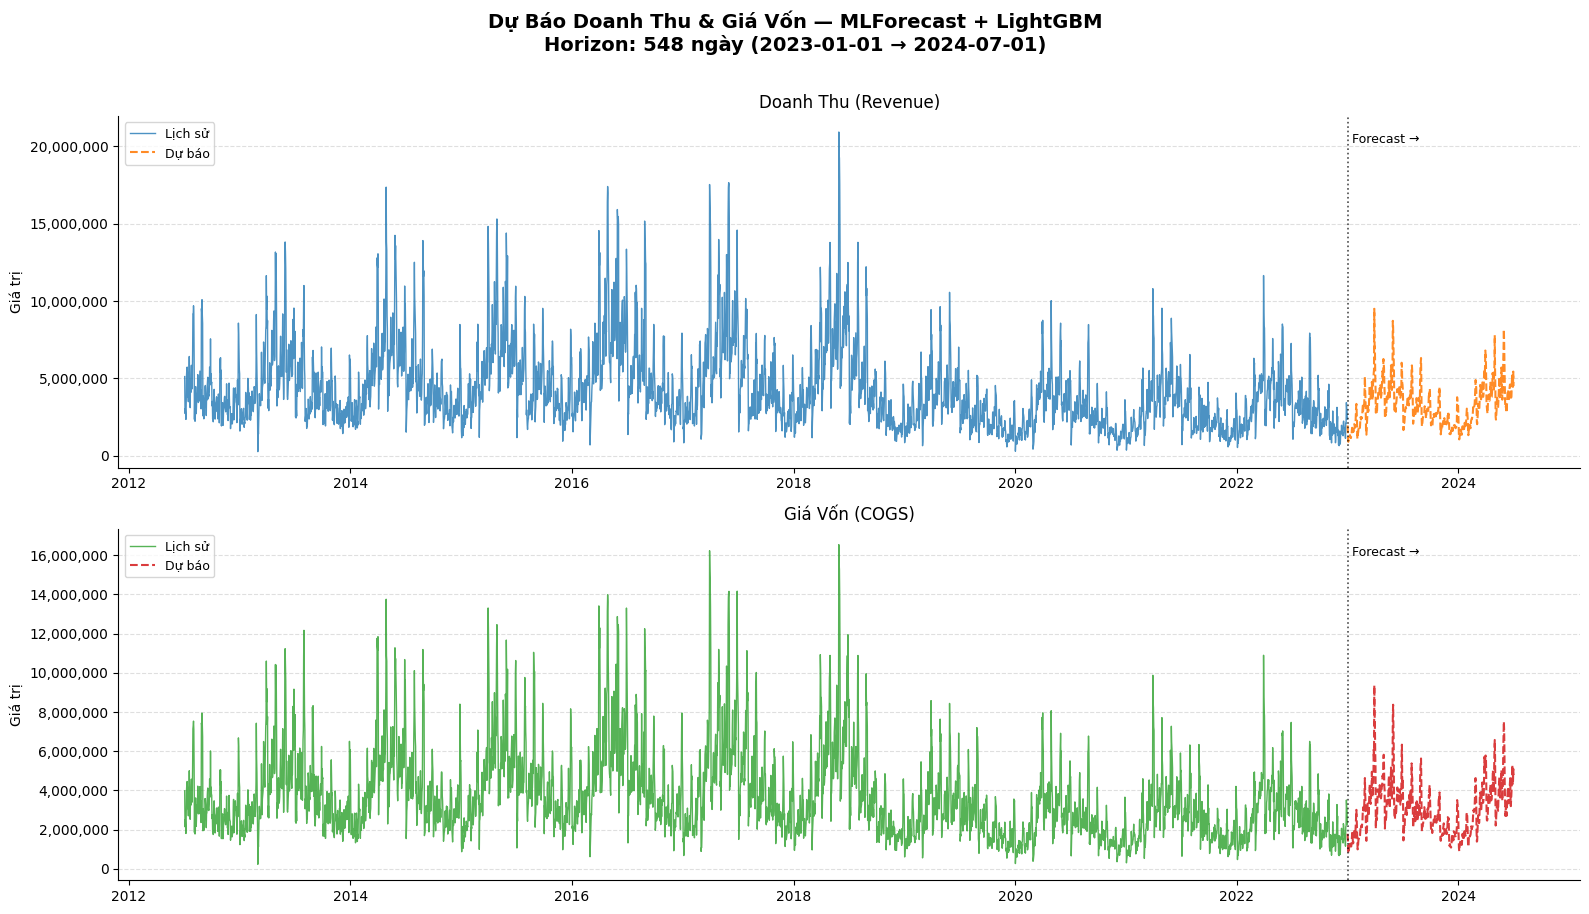

✅ Đã lưu forecast_visualization.png


In [12]:
# ============================================================
# BƯỚC 6: TRỰC QUAN HÓA — LỊCH SỬ VS. DỰ BÁO
# ============================================================

# Chuẩn bị dữ liệu lịch sử ở dạng Wide để vẽ cùng trục
df_history = (
    df_long
    .pivot(index="ds", columns="unique_id", values="y")
    .reset_index()
    .rename(columns={"ds": "Date"})
)
df_history.columns.name = None

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
fig.suptitle(
    "Dự Báo Doanh Thu & Giá Vốn — MLForecast + LightGBM\n"
    f"Horizon: {CONFIG['forecast_horizon']} ngày "
    f"({CONFIG['forecast_start']} → {str(submission['Date'].max().date())})",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

plot_cfg = [
    {"col": "Revenue", "hist_color": "#1f77b4", "fcast_color": "#ff7f0e", "label": "Doanh Thu (Revenue)"},
    {"col": "COGS",    "hist_color": "#2ca02c", "fcast_color": "#d62728", "label": "Giá Vốn (COGS)"},
]

for ax, cfg in zip(axes, plot_cfg):
    col = cfg["col"]

    # Vẽ lịch sử
    ax.plot(
        df_history["Date"], df_history[col],
        color=cfg["hist_color"], linewidth=1.0,
        alpha=0.8, label="Lịch sử",
    )

    # Vẽ dự báo
    ax.plot(
        submission["Date"], submission[col],
        color=cfg["fcast_color"], linewidth=1.5,
        linestyle="--", label="Dự báo", alpha=0.9,
    )

    # Đánh dấu ranh giới lịch sử / dự báo
    ax.axvline(
        x=pd.Timestamp(CONFIG["forecast_start"]),
        color="black", linewidth=1.2, linestyle=":", alpha=0.7,
    )
    ax.text(
        pd.Timestamp(CONFIG["forecast_start"]), ax.get_ylim()[1] * 0.95,
        " Forecast →", color="black", fontsize=9, va="top",
    )

    ax.set_title(cfg["label"], fontsize=12, pad=6)
    ax.set_ylabel("Giá trị", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(CONFIG["output_dir"], "forecast_visualization.png"),
    dpi=150, bbox_inches="tight",
)
plt.show()
print("✅ Đã lưu forecast_visualization.png")

## 🔍 BƯỚC 7 — PHÂN TÍCH KHẢ NĂNG GIẢI THÍCH (SHAP)

Sử dụng **SHAP TreeExplainer** để phân tích mức độ đóng góp của từng feature vào quyết định dự báo của mô hình LightGBM.

- **SHAP value dương** → Feature đẩy dự báo lên cao hơn baseline
- **SHAP value âm** → Feature kéo dự báo xuống thấp hơn baseline
- **Summary plot** thể hiện top features theo mức độ quan trọng toàn cục

⏳ Đang tính SHAP cho target: Revenue...


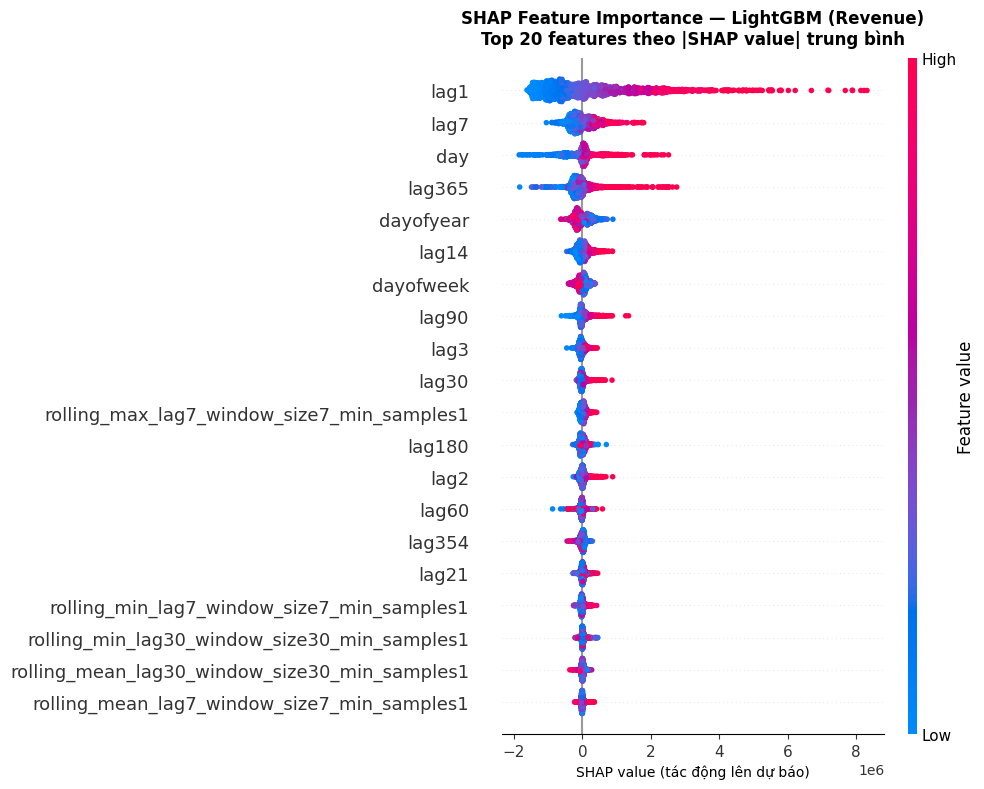

✅ Đã lưu SHAP summary plot: ../data/output\shap_summary.png


In [13]:
# ============================================================
# BƯỚC 7: PHÂN TÍCH SHAP EXPLAINABILITY
# ============================================================

def run_shap_analysis(
    fcst: MLForecast,
    df_long: pd.DataFrame,
    target_id: str,
    model_name: str,
    output_dir: str,
    output_filename: str,
    max_display: int = 20,
    sample_n: int = 2000,
) -> None:
    """
    Chạy SHAP TreeExplainer trên mô hình LightGBM đã train,
    vẽ và lưu summary_plot ra file ảnh.
    """
    print(f"⏳ Đang tính SHAP cho target: {target_id}...")

    # Lấy feature matrix qua preprocess (không có transforms parameter)
    X_full = fcst.preprocess(df_long, static_features=[])

    # Lọc chỉ lấy dữ liệu của target_id cần phân tích
    X_target = X_full[X_full["unique_id"] == target_id].copy()

    # Xác định cột feature (bỏ unique_id, ds, y)
    feature_cols = [
        c for c in X_target.columns
        if c not in ["unique_id", "ds", "y"]
    ]
    X_feat = X_target[feature_cols].dropna()

    # Lấy mẫu ngẫu nhiên để tăng tốc tính SHAP
    if len(X_feat) > sample_n:
        X_feat = X_feat.sample(n=sample_n, random_state=42)

    # Lấy mô hình LightGBM từ fcst.models_ (dict {model_name: estimator})
    raw_model = fcst.models_[model_name]

    explainer   = shap.TreeExplainer(raw_model)
    shap_values = explainer.shap_values(X_feat)

    # --- Vẽ Summary Plot ---
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.sca(ax)

    shap.summary_plot(
        shap_values,
        X_feat,
        max_display=max_display,
        show=False,
        plot_size=None,
    )

    ax.set_title(
        f"SHAP Feature Importance — LightGBM ({target_id})\n"
        f"Top {max_display} features theo |SHAP value| trung bình",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("SHAP value (tác động lên dự báo)", fontsize=10)

    plt.tight_layout()
    save_path = os.path.join(output_dir, output_filename)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"✅ Đã lưu SHAP summary plot: {save_path}")


# --- Chạy SHAP cho Revenue ---
run_shap_analysis(
    fcst=fcst,
    df_long=df_long,
    target_id="Revenue",
    model_name="LightGBM",
    output_dir=CONFIG["output_dir"],
    output_filename=CONFIG["shap_plot_filename"],
    max_display=20,
    sample_n=2000,
)

⏳ Đang tính SHAP cho target: COGS...


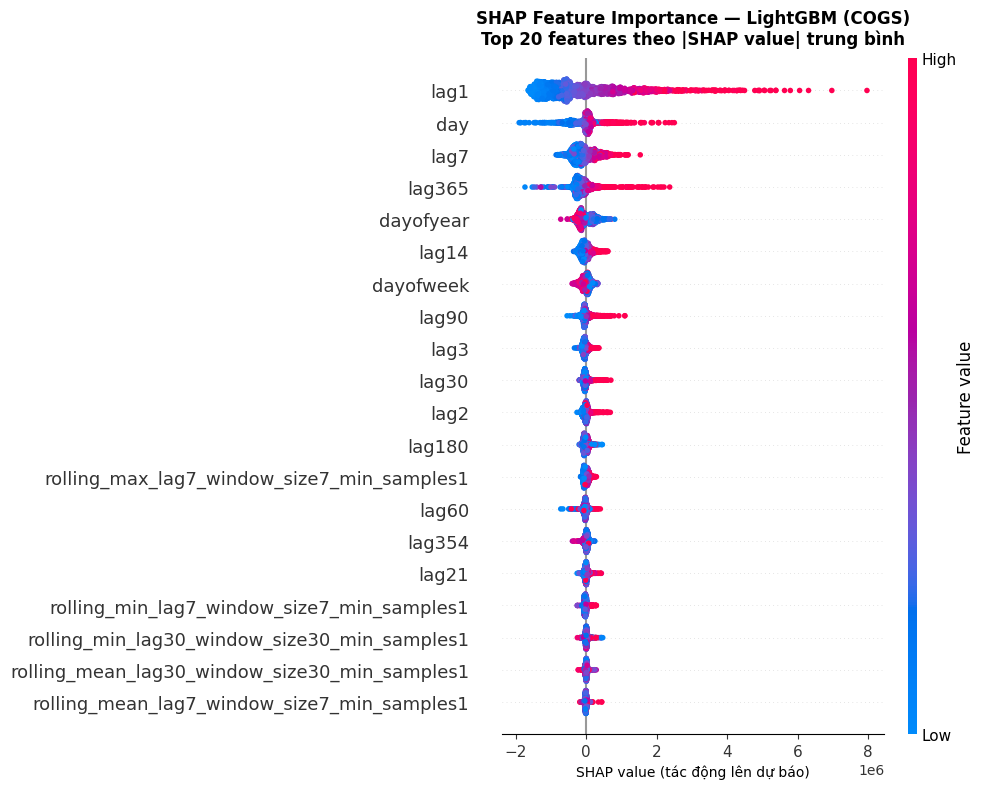

✅ Đã lưu SHAP summary plot: ../data/output\shap_summary_cogs.png


In [14]:
# --- (Tùy chọn) Chạy SHAP cho COGS ---
run_shap_analysis(
    fcst=fcst,
    df_long=df_long,
    target_id="COGS",
    model_name="LightGBM",
    output_dir=CONFIG["output_dir"],
    output_filename="shap_summary_cogs.png",
    max_display=20,
    sample_n=2000,
)

## ✅ TỔNG KẾT PIPELINE

| Bước | Mô tả | Trạng thái |
|------|--------|------------|
| 1    | Khai báo CONFIG (tập trung toàn bộ tham số) | ✅ |
| 2    | Đọc `sales.csv` & chuyển sang Long Format (`unique_id`, `ds`, `y`) | ✅ |
| 3    | Feature Engineering: `add_gregorian_peaks()` — sự kiện Dương lịch cố định | ✅ |
| 4    | Huấn luyện MLForecast + LightGBM (Direct Multi-step, lag 354 & 365) | ✅ |
| 5    | Pivot Long → Wide, lưu `submission.csv` | ✅ |
| 6    | Trực quan hóa lịch sử vs. dự báo | ✅ |
| 7    | SHAP Explainability — `shap_summary.png` | ✅ |

---

**Lưu ý điều chỉnh tham số:**
- Tất cả hyperparameters được tập trung trong `CONFIG` ở Bước 1.
- Để thêm/bỏ lag: chỉnh `CONFIG['lags']`.
- Để thêm ngày lễ: thêm entry vào `CONFIG['gregorian_peaks']`.
- Để tăng số cây (tránh underfitting): tăng `CONFIG['lgbm_params']['n_estimators']`.